# SOH Class 예측 AI모델 개발

## 개요
- 리튬이온 배터리의 건강상태(State-of-health: SOH)의 등급(Class) 추정 AI모델 개발

## 분석배경 
- 리튬이온 배터리는 충/방전 동작 및 저장 환경에 따라 전극 노화 및 반응 가능한 리튬이온의 감소로 사용 가능한 용량이 감소합니다.
- 사용 가능한 용량의 감소는 리튬이온 배터리가 사용되는 어플리케이션(전기자동차, 에너지저장장치 등)의 사용 시간을 감소시키는 매우 중요한 모니터링 인자로, 이를 건강상태(State-of-health: SOH)라고 합니다.
- 하지만, 리튬이온 배터리의 사용에 따른 노화를 추정하기 위해서는 비선형적인 배터리의 동작 특성에 따른 지표 선정과 이를 효율적으로 반영할 수 있는 분석 방법이 필요하며 
- 이를 바탕으로 리튬이온 배터리의 건강상태(State-of-health: SOH)의 등급(Class)을 추정하여 분류할 수 있는 AI 모델을 개발하고자 합니다.

## 평가 지표
- accuracy (정확도)

## 데이터 셋 정보

### [Data Files]
- train.csv: 학습용 데이터 (Features, Target) - 50,000건 
- test.csv:  예측용 데이터 (Features) - 50,000건

### [Feature]
- V0 ~ V7

### [Target]
- Class: 리튬이온 배터리의 건강상태 (0~4)

## 분석단계 
- **[step1] 라이브러리 및 데이터 불러오기**
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기 
 - (3) 데이터 확인  
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수별 분포 시각화  
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
 - (7) 스케일링 **(feature-양적변수만)**
- **[step4] 모델 설계**
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가 
- **[step5] 모델 선택 및 적용**
 - (1) test data의 예측값 생성
- **[step6] 결과 파일 생성**
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

## [Step1] 불러오기

### (1) 라이브러리 불러오기

In [1]:
# 데이터분석 라이브러리 불러오기
import pandas as pd
import numpy as np

#시각화를 위한 라이브러리 불러오기 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#AI모델 사용을 위한 라이브러리 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import ExtraTreesClassifier 

from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier

#모델링을 위한 함수 불러오기 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#future warning filter 불러오기
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### (2) 데이터 불러오기
**train data**

In [3]:
train = pd.read_csv('./train.csv')

In [4]:
train.head()

,ID,V0,V1,V2,V3,V4,V5,V6,V7,Class
0,TRAIN_00000,NaN,-0.063437,-0.083507,0.475347,-0.012022,-0.121974,NaN,0.047851,1
1,TRAIN_00001,-0.271026,-0.145173,NaN,NaN,0.012653,-0.092344,-0.030913,-0.052701,3
2,TRAIN_00002,-1.035352,NaN,-0.034443,-0.530655,0.001150,0.023062,-0.012697,0.058407,3
3,TRAIN_00003,-0.694365,NaN,0.071421,0.102912,0.399999,NaN,0.094365,NaN,0
4,TRAIN_00004,NaN,-0.092620,0.113638,0.104676,-0.031853,0.041083,-0.146752,-0.123120,3


**test data**

In [5]:
#정답
test = pd.read_csv('./test.csv')

In [6]:
# test data 확인
test.head()

,ID,V0,V1,V2,V3,V4,V5,V6,V7
0,TEST_00000,0.43832,0.008664,-0.108562,0.080903,0.018390,0.150824,0.315389,-0.119679
1,TEST_00001,NaN,0.025618,NaN,-0.012339,-0.011225,-0.052003,-0.000759,0.023875
2,TEST_00002,NaN,-0.072010,0.089537,-0.024380,0.011646,-0.318628,-0.225632,0.253589
3,TEST_00003,NaN,-0.262615,0.142379,-0.091961,-0.154997,0.224558,NaN,NaN
4,TEST_00004,NaN,-0.415798,NaN,NaN,0.079869,0.275429,0.269511,0.024939


### (3) 데이터 확인 
 - df.info()

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      50000 non-null  object 
 1   V0      39951 non-null  float64
 2   V1      40013 non-null  float64
 3   V2      40159 non-null  float64
 4   V3      39836 non-null  float64
 5   V4      40053 non-null  float64
 6   V5      40062 non-null  float64
 7   V6      39990 non-null  float64
 8   V7      39974 non-null  float64
 9   Class   50000 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 3.8+ MB


In [8]:
#정답
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      50000 non-null  object 
 1   V0      40135 non-null  float64
 2   V1      39993 non-null  float64
 3   V2      40007 non-null  float64
 4   V3      39950 non-null  float64
 5   V4      39963 non-null  float64
 6   V5      40144 non-null  float64
 7   V6      39957 non-null  float64
 8   V7      39870 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.4+ MB


## [Step2] 탐색적 데이터 분석 (EDA)

### (1) 기술통계분석
- describe()를 이용한 통계치 확인

In [9]:
train.describe()

,V0,V1,V2,V3,V4,V5,V6,V7,Class
count,39951.000000,40013.000000,40159.000000,39836.000000,40053.000000,40062.000000,39990.000000,39974.000000,50000.000000
mean,-0.002170,0.001493,-0.000191,0.000611,0.000455,0.000572,-0.000358,0.000817,2.313260
std,0.616873,0.176340,0.166273,0.163593,0.162170,0.159810,0.151977,0.151217,1.338418
min,-1.167258,-0.754546,-0.995570,-0.793750,-0.776659,-0.785080,-0.711145,-0.708901,0.000000
25%,-0.490101,-0.099416,-0.070225,-0.018816,-0.019721,-0.090024,-0.019932,-0.044479,1.000000
50%,-0.067643,-0.016537,0.003078,-0.000092,-0.000222,0.000912,-0.000230,-0.003676,2.000000
75%,0.457345,0.100593,0.078064,0.020320,0.017189,0.082559,0.018993,0.050770,3.000000
max,1.518668,0.977665,1.025999,0.772125,0.791807,0.861973,0.709650,0.795469,4.000000


In [10]:
test.describe()

,V0,V1,V2,V3,V4,V5,V6,V7
count,40135.000000,39993.000000,40007.000000,39950.000000,39963.000000,40144.000000,39957.000000,39870.000000
mean,-0.000200,-0.001290,0.000097,-0.000688,-0.001125,-0.000312,0.000299,-0.001379
std,0.611764,0.177132,0.167650,0.163555,0.162287,0.158076,0.150890,0.149783
min,-1.167289,-0.666994,-0.977027,-0.790033,-0.776417,-0.883172,-0.742959,-0.719021
25%,-0.480197,-0.100948,-0.069903,-0.019424,-0.020284,-0.087962,-0.019091,-0.046182
50%,-0.069719,-0.019145,0.003568,-0.000187,-0.000342,0.000776,0.000168,-0.004580
75%,0.453820,0.099168,0.079534,0.020902,0.016438,0.080337,0.019319,0.048616
max,1.506129,0.937866,1.087868,0.796121,0.794851,0.866021,0.752653,0.822374


### (2) 변수별 분포 시각화 
#### 1) 변수들간 상관관계를 보여주는 pairplot

<Figure size 1500x1500 with 0 Axes>

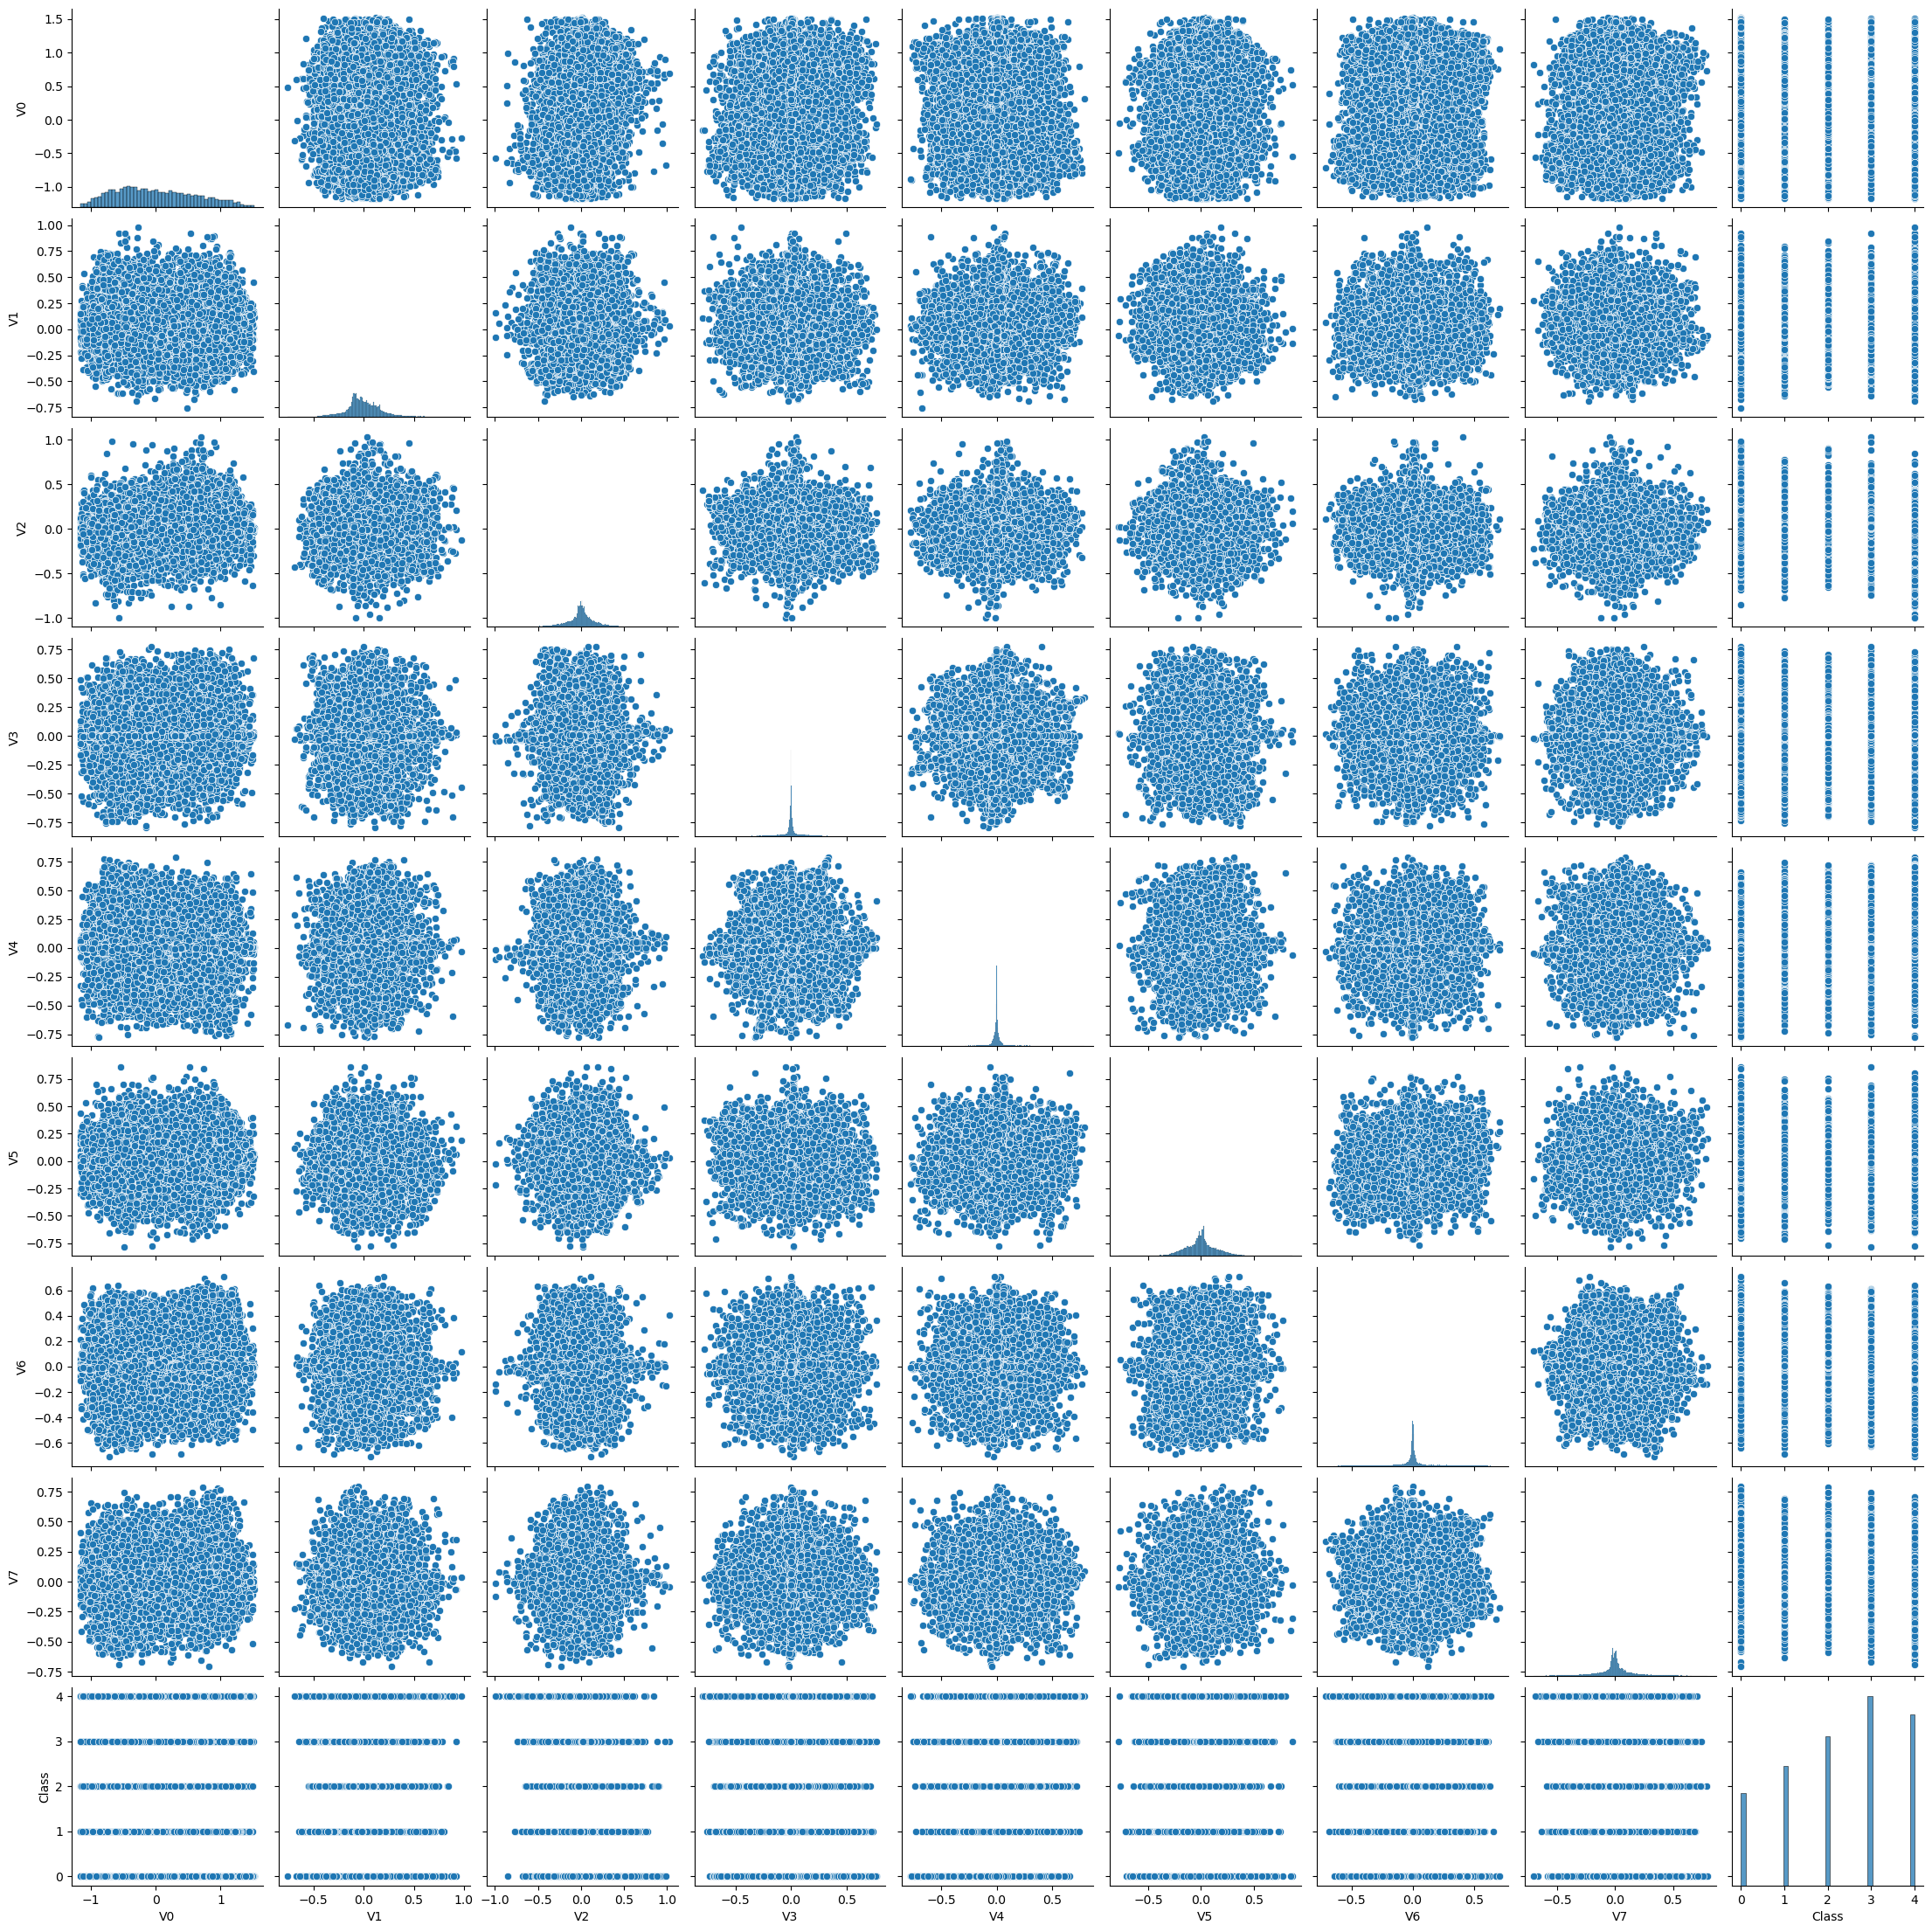

In [11]:
#정답예시
plt.figure(figsize = (15,15))
sns.pairplot(train) 
#또는 sns.pairplot(train,hue='Class' ), 또는 sns.pairplot(train[['V0', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'Class']])

plt.show()

**[정리] 변수들간 선형관계가 없는 것을 확인할 수 있다**

#### 2) 연속형 (양적) 변수의 분포를 보여주는 histplot 
- V0~V7

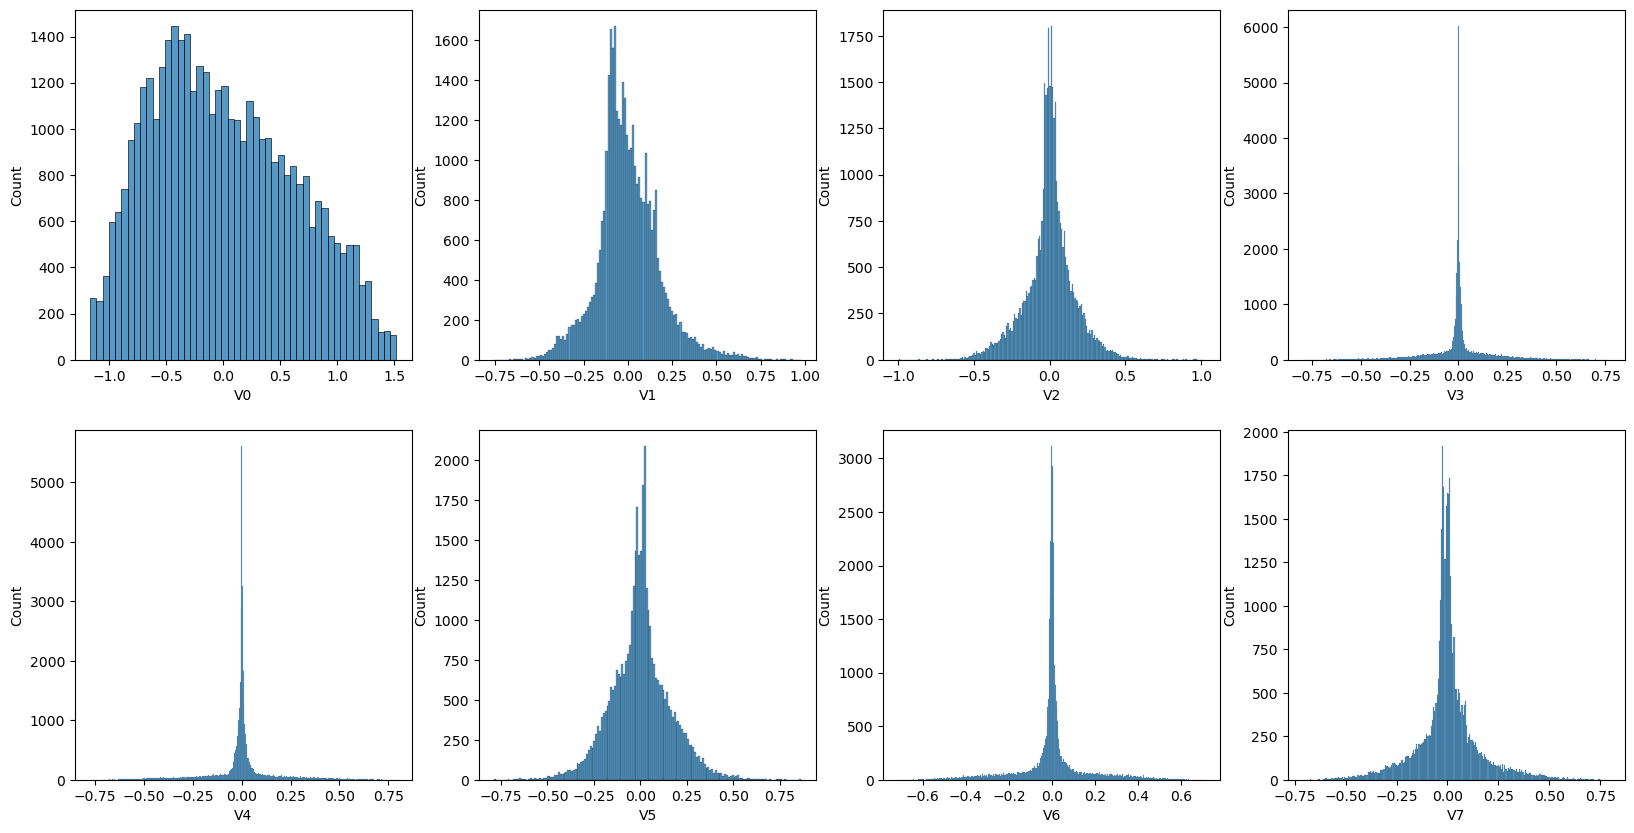

In [12]:
#정답
fig, axes = plt.subplots(2, 4, figsize=(20,10))

sns.histplot(x = train['V0'], ax=axes[0][0])
sns.histplot(x = train['V1'], ax=axes[0][1])
sns.histplot(x = train['V2'], ax=axes[0][2])
sns.histplot(x = train['V3'], ax=axes[0][3])
sns.histplot(x = train['V4'], ax=axes[1][0])
sns.histplot(x = train['V5'], ax=axes[1][1])
sns.histplot(x = train['V6'], ax=axes[1][2])
sns.histplot(x = train['V7'], ax=axes[1][3])
plt.show()

#### 3) 범주형 (질적) 변수의 빈도를 보여주는 countplot
- Class(target)

Text(0.5, 1.0, 'Class')

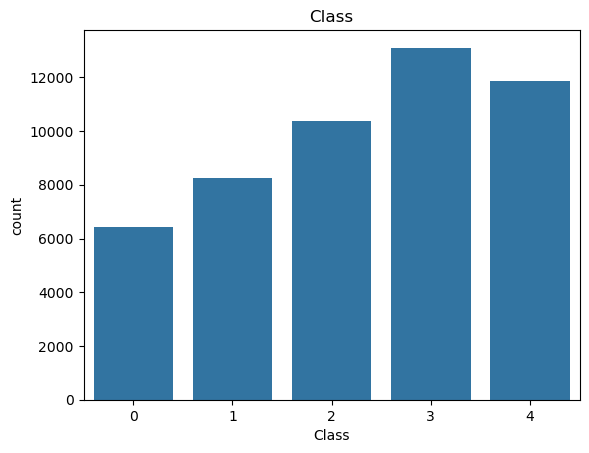

In [13]:
sns.countplot(x = train['Class']).set_title('Class')

 - Class(배터리 등급)에 있어 큰 불균형 없음
 - 하지만 등급별 데이터 건수를 동일하게 하여 불균형데이터를 균형데이터로 변환은 가능
     - 모든 데이터의 수량을 **가장 건수가 많은 3등급** 과 동일하게 조정함
     - **주의1) 훈련데이터** 에만 적용. 검증(validation)이나 테스트 데이터에는 적용하지 않음
         - 검증/테스트는 **실제 분포를 반영** 해야 평가가 의미 있기 때문
     - **주의2) 스케이링 이후** 에만 적용. 스케일링이 안 된 상태에서 적용하면 스케일이 큰 변수에 휘둘림 
     - 일반적으로 1:10 정도의 압도적 불균형이 있을때 권장
     - 현재와 같은 경우는 큰 불균형성이 없기 때문에 오히려 성능이 떨어질수도 있음     

## [step3] 데이터 전처리

### (1) 중복값 처리 **(Train셋만)**

In [14]:
# train 셋의 중복값 확인
train.duplicated().sum()

np.int64(0)

##### [주의1]
- 만약 train data 에 중복값이 있다면?
    - df.drop_duplicates()를 이용하여 중복행을 제거
    - 회귀 파트에서 다룰 예정
    
##### [주의2]
- test 셋의 경우 예측 후 제출 파일과 데이터 건수가 동일해야 함
- 따라서 **test 셋에 대해서는 중복에 의한 제거처리를 하지 않음**

### (2) 불필요한 Feature 삭제

In [15]:
# ID column 삭제 -train set
train.drop(['ID'], axis=1, inplace=True)
train

,V0,V1,V2,V3,V4,V5,V6,V7,Class
0,NaN,-0.063437,-0.083507,0.475347,-0.012022,-0.121974,NaN,0.047851,1
1,-0.271026,-0.145173,NaN,NaN,0.012653,-0.092344,-0.030913,-0.052701,3
2,-1.035352,NaN,-0.034443,-0.530655,0.001150,0.023062,-0.012697,0.058407,3
3,-0.694365,NaN,0.071421,0.102912,0.399999,NaN,0.094365,NaN,0
4,NaN,-0.092620,0.113638,0.104676,-0.031853,0.041083,-0.146752,-0.123120,3
...,...,...,...,...,...,...,...,...,...
49995,-0.897280,0.198602,0.027603,0.125120,0.300453,NaN,-0.105906,0.056823,4
49996,NaN,-0.020727,-0.030771,NaN,0.005013,NaN,0.032835,0.118511,2
49997,0.582378,-0.018754,-0.012226,-0.011277,NaN,-0.028654,0.003075,NaN,1
49998,NaN,0.114867,-0.015775,0.012714,-0.015274,0.143736,0.088785,-0.110537,4


In [16]:
# ID column 삭제 -test set
test.drop(['ID'], axis=1, inplace=True)
test

,V0,V1,V2,V3,V4,V5,V6,V7
0,0.438320,0.008664,-0.108562,0.080903,0.018390,0.150824,0.315389,-0.119679
1,NaN,0.025618,NaN,-0.012339,-0.011225,-0.052003,-0.000759,0.023875
2,NaN,-0.072010,0.089537,-0.024380,0.011646,-0.318628,-0.225632,0.253589
3,NaN,-0.262615,0.142379,-0.091961,-0.154997,0.224558,NaN,NaN
4,NaN,-0.415798,NaN,NaN,0.079869,0.275429,0.269511,0.024939
...,...,...,...,...,...,...,...,...
49995,-0.132452,0.281816,0.228475,-0.261477,0.549440,0.635909,-0.186036,0.171476
49996,0.705232,-0.012156,0.006206,-0.273154,NaN,-0.086448,0.282508,NaN
49997,-0.388839,0.084974,0.145287,-0.420798,NaN,0.270230,-0.098514,-0.086113
49998,1.133047,0.124206,NaN,-0.007631,0.007239,0.043837,NaN,0.067809


### (3) 결측치 처리

- train과 test의 결측치 확인

In [17]:
# train data의 결측치 확인
train.isnull().sum()

V0       10049
V1        9987
V2        9841
V3       10164
V4        9947
V5        9938
V6       10010
V7       10026
Class        0
dtype: int64

In [18]:
# test- train과 test의 결측치 확인 data의 결측치 확인
test.isnull().sum()

V0     9865
V1    10007
V2     9993
V3    10050
V4    10037
V5     9856
V6    10043
V7    10130
dtype: int64

- **impute** : (없는 값을) 추정해서 채워 넣음

In [20]:
from sklearn.experimental import enable_iterative_imputer  # IterativeImputer는 experimental이라 추가 import
from sklearn.impute import KNNImputer, IterativeImputer

- KNNImputer 
    - 결측이 있는 샘플의 **가장 가까운  K개 이웃의 평균** 으로 결측값 보간
    - 단순/직관적 방식
- IterativeImputer
    - **ML** 에 의한 데이터 보간법
    - 각 결측 변수를 **다른 변수들의 회귀 모델** 로 예측해서 채움 
    - 이걸 변수마다 반복해서 수렴할 때까지 돌림 
    - 변수 간 비선형 관계까지 잡아낼 수 있음.
    - 더 정교한 방식 

In [21]:
# 보간이 필요한 컬럼 설정
impute_cols = ['V0', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']

In [23]:
#Imputer 선택
imputer = KNNImputer(n_neighbors=5)   # 1. KNNImputer 사용
#imputer = IterativeImputer(random_state=10, max_iter=10)  # 2.IterativeImputer 사용

# fit은 train으로만, transform은 둘 다
train[impute_cols] = imputer.fit_transform(train[impute_cols])
test[impute_cols] = imputer.transform(test[impute_cols])

#### [참고] 
- pairplot 결과에서도 보듯이 이 경우는 변수간 상관관계가 없기 때문에 iterative보간이 별 효과가 없음
- ML 보간이 평균 보간 대비 추가로 끌어낼 정보가 별로 없다는 것.
- 이럴 경우, KNNKNNImputer를 쓰거나 단순 평균 보간으로도 충분함

- 결측치 처리가 되었음을 확인

In [24]:
#정답
# train data 결측치 대체 완료 확인 
train.isnull().sum()

V0       0
V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
Class    0
dtype: int64

In [25]:
#정답
# test data 결측치 대체 완료 확인 
test.isnull().sum()

V0    0
V1    0
V2    0
V3    0
V4    0
V5    0
V6    0
V7    0
dtype: int64

### (4) 아웃라이어 제거  **(Train셋 & 양적변수만)**
- **[데이터셋]**
    - **train셋** 에 적용
    - train셋은 모델이 일반화된 패턴을 배우는 구간, 아웃라이어가 모델 학습에 악영향을 줄 수 있기 때문에 **아웃라이어 제거**
    - test셋은 모델의 성능을 평가하기 위한 처음 접하는(unseen) 데이터, **test 데이터 손대지 않음**
- **[대상 변수]** 
    - **target** 아웃라이어 처리
        - 회귀모델에서 target의 극단적인 값은 모델 왜곡 가능, 예측 성능에 큰 영향
    - **feature** 아웃라이어 처리
        - feature 아웃라이어도 모델 학습에 영향 가능(특히 **target과 강한 상관관계** 때)
        - 하지만, 모든 feature를 다 아웃라이어 처리하다보면 데이터 유실이 심해짐
        - **일단 모델링을 하고 feature importance 뽑아서 후처리**도 전략 
            - 영향력 높은 feature만 따로 아웃라이어 처리
- **[아웃라이어 제거 순위]**
  - 1순위: train셋의 target(**회귀모델**일 경우)
  - 2순위: train셋의 feature
  - 단, 변수의 아웃라이어가 자연스러운 변동일 경우에는 제거하지 않는 것이 좋으므로 신중하게 수행

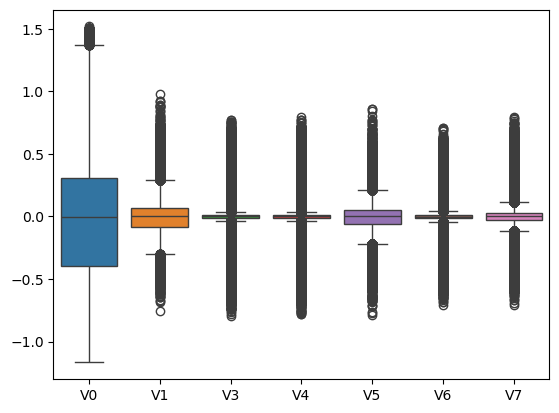

In [26]:
# 분류모델이므로 train셋의 feature를 대상으로 아웃라이어 확인 - boxplotting
sns.boxplot(data=train[["V0","V1","V3","V4","V5","V6","V7"]])
plt.show()

In [27]:
#'V0'에서 상단 아웃라이어 제거 -  train['V0']<=1.5 인 데이터만 남김
train=train[train['V0']<=1.5 ]
train   # 50,000개 --> ??개

,V0,V1,V2,V3,V4,V5,V6,V7,Class
0,-0.002564,-0.063437,-0.083507,0.475347,-0.012022,-0.121974,-0.000813,0.047851,1
1,-0.271026,-0.145173,-0.000309,0.000884,0.012653,-0.092344,-0.030913,-0.052701,3
2,-1.035352,0.001359,-0.034443,-0.530655,0.001150,0.023062,-0.012697,0.058407,3
3,-0.694365,0.001457,0.071421,0.102912,0.399999,0.000252,0.094365,0.000553,0
4,-0.002354,-0.092620,0.113638,0.104676,-0.031853,0.041083,-0.146752,-0.123120,3
...,...,...,...,...,...,...,...,...,...
49995,-0.897280,0.198602,0.027603,0.125120,0.300453,-0.000647,-0.105906,0.056823,4
49996,-0.002273,-0.020727,-0.030771,0.000749,0.005013,0.002956,0.032835,0.118511,2
49997,0.582378,-0.018754,-0.012226,-0.011277,0.000617,-0.028654,0.003075,-0.000277,1
49998,-0.002160,0.114867,-0.015775,0.012714,-0.015274,0.143736,0.088785,-0.110537,4


### (5) Feature, Target 설정
- train 셋: Feature / Target 으로 분리
- test 셋: Feature만 설정

In [28]:
# train set - features 설정
Xtrain=train.drop(['Class'], axis=1)
Xtrain

,V0,V1,V2,V3,V4,V5,V6,V7
0,-0.002564,-0.063437,-0.083507,0.475347,-0.012022,-0.121974,-0.000813,0.047851
1,-0.271026,-0.145173,-0.000309,0.000884,0.012653,-0.092344,-0.030913,-0.052701
2,-1.035352,0.001359,-0.034443,-0.530655,0.001150,0.023062,-0.012697,0.058407
3,-0.694365,0.001457,0.071421,0.102912,0.399999,0.000252,0.094365,0.000553
4,-0.002354,-0.092620,0.113638,0.104676,-0.031853,0.041083,-0.146752,-0.123120
...,...,...,...,...,...,...,...,...
49995,-0.897280,0.198602,0.027603,0.125120,0.300453,-0.000647,-0.105906,0.056823
49996,-0.002273,-0.020727,-0.030771,0.000749,0.005013,0.002956,0.032835,0.118511
49997,0.582378,-0.018754,-0.012226,-0.011277,0.000617,-0.028654,0.003075,-0.000277
49998,-0.002160,0.114867,-0.015775,0.012714,-0.015274,0.143736,0.088785,-0.110537


In [29]:
# train set -- target 설정
ytrain=train['Class']
ytrain

0        1
1        3
2        3
3        0
4        3
        ..
49995    4
49996    2
49997    1
49998    4
49999    1
Name: Class, Length: 49985, dtype: int64

In [30]:
# test set - features
Xtest=test.copy()
Xtest

,V0,V1,V2,V3,V4,V5,V6,V7
0,0.438320,0.008664,-0.108562,0.080903,0.018390,0.150824,0.315389,-0.119679
1,-0.002099,0.025618,-0.000215,-0.012339,-0.011225,-0.052003,-0.000759,0.023875
2,-0.002136,-0.072010,0.089537,-0.024380,0.011646,-0.318628,-0.225632,0.253589
3,-0.002502,-0.262615,0.142379,-0.091961,-0.154997,0.224558,0.001722,0.003721
4,-0.002495,-0.415798,-0.000166,0.000786,0.079869,0.275429,0.269511,0.024939
...,...,...,...,...,...,...,...,...
49995,-0.132452,0.281816,0.228475,-0.261477,0.549440,0.635909,-0.186036,0.171476
49996,0.705232,-0.012156,0.006206,-0.273154,0.000581,-0.086448,0.282508,-0.003303
49997,-0.388839,0.084974,0.145287,-0.420798,-0.000349,0.270230,-0.098514,-0.086113
49998,1.133047,0.124206,0.000087,-0.007631,0.007239,0.043837,0.000894,0.067809


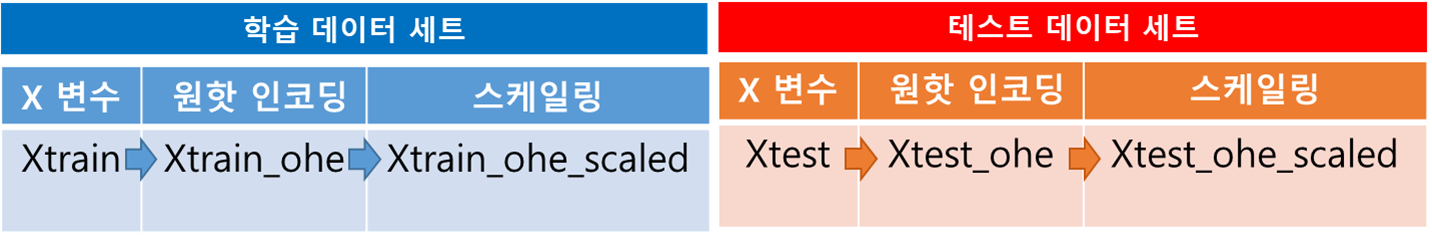

### (6) 원핫 인코딩 **(feature-질적변수만)**
- get_dummies(df, columns=[해당 column명])
- **feature** 중 **카테고리 변수**에 대해서 수행 
- 하지만 본 프로젝트에서는 feature에 카테고리 변수가 없으므로 이 과정을 생략

In [31]:
# 본 프로젝트에서는 필요없는 과정이나 향후 원핫인코딩이 필요한 분류문제를 위해 이 과정을 남겨둠
# 현재는 원핫인코딩이 필요없으므로 기존 df을 단순 복사만 해둠
#실제 필요시 처리과정은 회귀파트에 다룰 예정
Xtrain_ohe=Xtrain.copy()  
Xtest_ohe=Xtest.copy()  

### (7) 스케일링 **(feature-양적변수만)**
- 스케일링을 통해 변수들의 데이터 분포나 범위를 조정

**[주의] 스케일링 시 주의사항**
- fit (스케일링을 위한 계산 수행): train data
- transform(적용): train data & test data 

**train data**
###### 1) MinMaxScaling
- 스케일후df= minmax_scaler.**fit_transform**(스케일전df)

###### 2) StandardScaling
- 스케일후df= standard_scaler.**fit_transform**(스케일전df)

In [32]:
from sklearn.preprocessing import StandardScaler

#object 선언
standard_scaler = StandardScaler()

In [33]:
# 결과 DF를 미리 생성
Xtrain_ohe_scaled=Xtrain_ohe.copy()

# 스케일링이 필요한 변수만 나열
Xtrain_ohe_scaled[['V0','V1','V2','V3','V4','V5','V6','V7']]=standard_scaler.fit_transform(Xtrain_ohe[['V0','V1','V2','V3','V4','V5','V6','V7']])
Xtrain_ohe_scaled  #스케일링 결과 확인

,V0,V1,V2,V3,V4,V5,V6,V7
0,0.000106,-0.411466,-0.559121,3.251478,-0.085986,-0.856543,-0.003397,0.347779
1,-0.487237,-0.929660,-0.000854,0.001981,0.083992,-0.649425,-0.224824,-0.395786
2,-1.874733,-0.000675,-0.229898,-3.638416,0.004754,0.157272,-0.090817,0.425839
3,-1.255732,-0.000054,0.480467,0.700747,2.752383,-0.002174,0.696783,-0.001980
4,0.000488,-0.596483,0.763746,0.712830,-0.222606,0.283243,-1.076997,-0.916526
...,...,...,...,...,...,...,...,...
49995,-1.624088,1.249809,0.186438,0.852848,2.066618,-0.008457,-0.776512,0.414128
49996,0.000634,-0.140696,-0.205259,0.001054,0.031361,0.016728,0.244139,0.870300
49997,1.061962,-0.128186,-0.080818,-0.081308,0.001080,-0.204226,0.025206,-0.008117
49998,0.000839,0.718946,-0.104633,0.083004,-0.108389,1.000798,0.655736,-0.823473


In [34]:
Xtrain_ohe_scaled.min()

V0   -2.114185
V1   -4.792963
V2   -6.679175
V3   -5.440294
V4   -5.353496
V5   -5.491715
V6   -5.228966
V7   -5.248283
dtype: float64

In [35]:
Xtrain_ohe_scaled.max()

V0    2.727678
V1    6.188916
V2    6.885802
V3    5.284049
V4    5.451509
V5    6.021340
V6    5.223144
V7    5.876305
dtype: float64

**test data**
###### 1) MinMaxScaling
- 스케일후df= minmax_scaler.**transform**(스케일전df)

###### 2) StandardScaling
- 스케일후df= standard_scaler.**transform**(스케일전df)

In [36]:
# test 셋의 결과 DF 미리 생성
Xtest_ohe_scaled = Xtest_ohe.copy()

In [37]:
Xtest_ohe_scaled[['V0','V1','V2','V3','V4','V5','V6','V7']]=standard_scaler.transform(Xtest_ohe[['V0','V1','V2','V3','V4','V5','V6','V7']])
Xtest_ohe_scaled  #스케일링 결과 확인

,V0,V1,V2,V3,V4,V5,V6,V7
0,0.800452,0.045639,-0.727245,0.550014,0.123514,1.050344,2.322755,-0.891078
1,0.000950,0.153123,-0.000219,-0.088580,-0.080496,-0.367441,-0.002993,0.170481
2,0.000882,-0.465817,0.602026,-0.171048,0.077055,-2.231170,-1.657280,1.869183
3,0.000219,-1.674218,0.956604,-0.633895,-1.070928,1.565751,0.015258,0.021450
4,0.000232,-2.645369,0.000105,0.001308,0.547038,1.921342,1.985248,0.178353
...,...,...,...,...,...,...,...,...
49995,-0.235682,1.777368,1.534319,-1.794875,3.781869,4.441126,-1.365992,1.261968
49996,1.284981,-0.086354,0.042861,-1.874845,0.000829,-0.608209,2.080862,-0.030493
49997,-0.701105,0.529429,0.976112,-2.886030,-0.005578,1.884999,-0.722135,-0.642861
49998,2.061602,0.778152,0.001802,-0.056333,0.046695,0.302494,0.009165,0.495365


In [38]:
Xtest_ohe_scaled.min()

V0   -2.114241
V1   -4.237903
V2   -6.554751
V3   -5.414840
V4   -5.351831
V5   -6.177382
V6   -5.463009
V7   -5.323120
dtype: float64

In [39]:
Xtest_ohe_scaled.max()

V0    2.738864
V1    5.936596
V2    7.300949
V3    5.448389
V4    5.472481
V5    6.049635
V6    5.539499
V7    6.075264
dtype: float64

## [step4] 모델 설계 
 - 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
 - 다양한 모델의 성능비교 실시 
  - Logistic Regression, DecisioTree, Knn
  - 트리기반 모델 중 배깅 기법을 적용한 Random Forest, ExtraTree, 
  - 트리기반 모델 중 부스팅 기법을 적용한 XGBoost와 Light GBM 
 

- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 생성
 - test_size = 0.2
 - random_state = 10

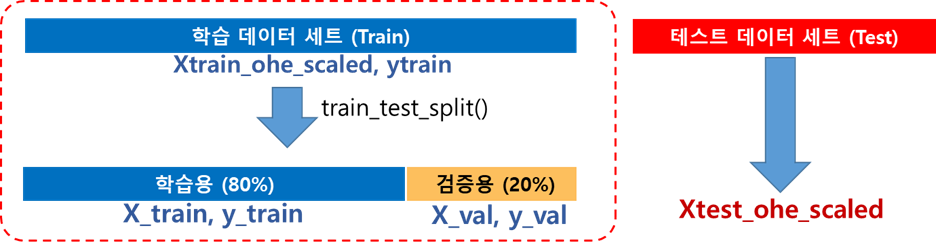

### (1) 훈련 및 검증 데이터 분할

In [40]:
# 데이터 분할: test_size=0.2, random_state=10

X_train, X_val, y_train, y_val = train_test_split(Xtrain_ohe_scaled, ytrain, test_size=0.2, random_state=10)

### (1)-2 Oversampling을 통한 불균형데이터 처리 (선택사항)

- 모든 데이터의 수량을 **가장 건수가 많은 3등급** 과 동일하게 조정함
- **주의1) 훈련데이터** 에만 적용. 검증(validation)이나 테스트 데이터에는 적용하지 않음
     - 검증/테스트는 **실제 분포를 반영** 해야 평가가 의미 있기 때문
- **주의2) 스케이링 이후** 에만 적용. 스케일링이 안 된 상태에서 적용하면 스케일이 큰 변수에 휘둘림 
- 일반적으로 1:10 정도의 압도적 불균형이 있을때 권장

In [41]:
from imblearn.over_sampling import SMOTE


# SMOTE 적용 - 훈련 데이터에만!
smote = SMOTE(random_state=10)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [42]:
print('\nSMOTE 적용 후 y_train 분포:')
print(y_train.value_counts())


SMOTE 적용 후 y_train 분포:
Class
3    10438
2    10438
1    10438
4    10438
0    10438
Name: count, dtype: int64


### (2) 평가지표 확인
- 평가지표가 accuracy이므로 skleran의 accuracy_score() 함수 사용

### (3) 알고리즘별 학습, 예측, 평가 실시 

- 반복 작업을 for문으로 처리!

In [43]:
# 1) Logistic Regression ~ 7) LGBM Regressor

models = {    
    'LogisticRegression': LogisticRegression(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'Random Forest Classifier': RandomForestClassifier(n_jobs=-1),
    'Extra Trees Classifier': ExtraTreesClassifier(n_jobs=-1),
    'XGB Classifier' : XGBClassifier(verbose=-1,n_jobs=-1),
    'LGBM Classifier' : LGBMClassifier(verbose=-1,n_jobs=-1)
}

In [44]:
# 모델 학습 및 평가
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_val)
    score = accuracy_score(y_val, pred)
    print(f'[{name} 모델의 accuracy ]: {round(score, 4)}')

[LogisticRegression 모델의 accuracy ]: 0.4483
[Decision Tree Classifier 모델의 accuracy ]: 0.4742
[KNeighborsClassifier 모델의 accuracy ]: 0.5179
[Random Forest Classifier 모델의 accuracy ]: 0.6261
[Extra Trees Classifier 모델의 accuracy ]: 0.6324
[XGB Classifier 모델의 accuracy ]: 0.6341
[LGBM Classifier 모델의 accuracy ]: 0.6335


- 최적의 모델을 어떻게 기억해야 할까?

In [45]:
# 초기화: selected_estimator, max_score
selected_estimator = None
max_score = 0

In [46]:
# 모델 학습 및 평가
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_val)
    score = accuracy_score(y_val, pred)
    print(f'[{name} 모델의 accuracy ]: {round(score, 4)}')

    if score > max_score:
        selected_estimator = estimator
        max_score = score
        print('selected estimator: {}'.format(name))
    print('')

[LogisticRegression 모델의 accuracy ]: 0.4483
selected estimator: LogisticRegression

[Decision Tree Classifier 모델의 accuracy ]: 0.4739
selected estimator: Decision Tree Classifier

[KNeighborsClassifier 모델의 accuracy ]: 0.5179
selected estimator: KNeighborsClassifier

[Random Forest Classifier 모델의 accuracy ]: 0.6278
selected estimator: Random Forest Classifier

[Extra Trees Classifier 모델의 accuracy ]: 0.6285
selected estimator: Extra Trees Classifier

[XGB Classifier 모델의 accuracy ]: 0.6341
selected estimator: XGB Classifier

[LGBM Classifier 모델의 accuracy ]: 0.6335



**[정리] 가장 정확도가 높은 모델을 사용하기로 결정** 
- https://xgboost.readthedocs.io/en/stable/parameter.html
- https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

In [47]:
selected_estimator

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### (4) 하이퍼 파라미터 튜닝
- 검증 데이터셋을 이용한 평가에서 가장 좋은 성능을 보인 모델의 하이퍼 파라미터 튜닝
- 3개의 파라미터 **(max_depth, learning_rate, n_estimators)** 튜닝

- 튜닝전에, default parameter일때의 성능을 Cross Validation 기반 재검증

In [48]:
from sklearn.model_selection import GridSearchCV

# 1) (Cross Validation이 목적이므로) 파라미터 설정은 하지 않음
parameters ={}

# 2) GridSearchCV 설정: 
grid_search = GridSearchCV(selected_estimator, 
                           parameters,
                           cv=5,
                           scoring='accuracy')

# 3) GridSearchCV estimator로 학습: 
grid_search.fit(Xtrain_ohe_scaled, ytrain)

# 4) Score확인
print('최적 하이퍼 파라미터 score: ', grid_search.best_score_)

최적 하이퍼 파라미터 score:  0.6336500950285087


- 실제 하이퍼파라미터 튜닝 시작!

In [49]:
# 현재의 default 파라미터 확인
selected_estimator.get_params()

{'objective': 'multi:softprob',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'verbose': -1}

In [50]:
param_grid = {'max_depth': [None, 6, 10],                   
     'learning_rate':[None, 0.1, 0.3],             
     'n_estimators': [100, 200, 300]          #default 100
    }    

grid_search = GridSearchCV(selected_estimator, 
                           param_grid,
                           cv=5,
                           scoring='accuracy')                           
    
grid_search.fit(Xtrain_ohe_scaled, ytrain)

print('최적 하이퍼 파라미터 : ', grid_search.best_params_)
print('score : ', grid_search.best_score_)

최적 하이퍼 파라미터 :  {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}
score :  0.6359107732319697


- 한꺼번에 진행하면,,,, (3 * 3 * 4 * 5)
    - 너무 많은 조합으로 시간이 너무 오래 걸림. 따라서,
    - 먼저 max_depth,  변화에 따른 성능 변화를 확인
    - 이후 learning_rate, n_estimators 순으로 튜닝을 진행함

#### 1) 1차 GridSearchCV
- 먼저 max_depth 변화에 따른 성능 변화를 확인

#### 2) 2차 GridSearchCV
- learning_rate 변화에 따른 성능 변화를 확인

#### 3) 3차 GridSearchCV
- n_estimators 변화에 따른 성능 변화를 확인

## [step5] 모델 선택 및 적용
### (1) test data의 예측값 생성
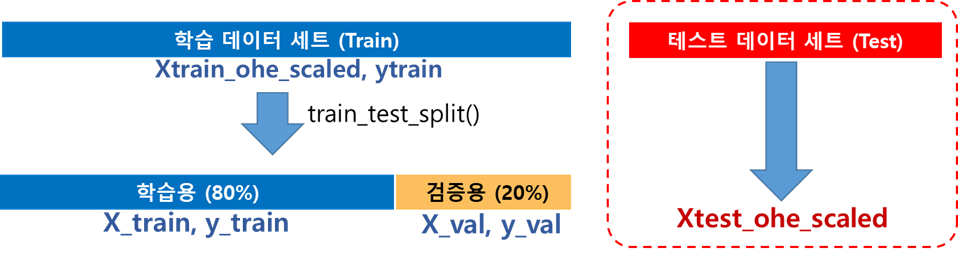

In [51]:
#튜닝된 모델로 예측하기 
pred_test = grid_search.best_estimator_.predict(Xtest_ohe_scaled)

### (2) 실제값과 예측값의 분포 비교

<Axes: ylabel='count'>

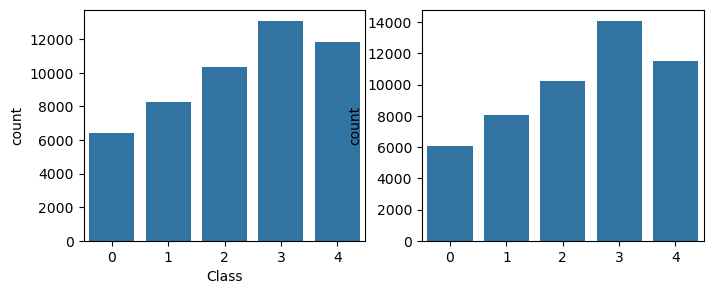

In [52]:
fig, axs = plt.subplots(1,2, figsize=(8,3))
sns.countplot(x=ytrain, ax=axs[0])
sns.countplot(x=pred_test, ax=axs[1])

- SMOTE oversampling은 모델에게 "이 클래스를 더 많이 예측해라" 라고 강제하는 것이 아님
- 그냥 학습 데이터에서 "소수 클래스 패턴을 좀 더 자주 보여줘서 더 잘 배우게 하는 것" 임
- 모델이 진짜로 배우는 건, 아래의 관계
    - "이런 feature 패턴이 들어오면 → Class X일 가능성이 높다"
    - 이 관계 자체는 SMOTE 전후로 변하지 않음

## [step6] 결과 파일 생성 
### (1) 예시 파일 불러오기 

In [53]:
#예시 파일 불러오기
submission = pd.read_csv('./sample_submission.csv')
submission.head(5)

,ID,Class
0,TEST_00000,0
1,TEST_00001,0
2,TEST_00002,0
3,TEST_00003,0
4,TEST_00004,0


In [54]:
#test data의 예측 결과 저장하기
submission['Class'] = pred_test
submission.head(5)

,ID,Class
0,TEST_00000,1
1,TEST_00001,1
2,TEST_00002,4
3,TEST_00003,3
4,TEST_00004,0


In [55]:
#정답

#제출 파일 생성하기
submission.to_csv('./submission.csv', index=False)

**수고하셨습니다** 